# 05 - Final Analysis

## Dataset: hourlySteps_clean.csv

### Programación para la Ciencia de Datos

## Objetivo
Integrar los resultados obtenidos durante todo el proyecto de Machine Learning, incluyendo:

- Análisis exploratorio.
- Modelos supervisados.
- Evaluación comparativa.
- Optimización de hiperparámetros.
- Selección del modelo final.
- Conclusiones y recomendaciones.

Este notebook funciona como cierre técnico del proyecto.

In [1]:
# ========================================
# LIBRERÍAS
# ========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [2]:
# ========================================
# CARGA DEL DATASET
# ========================================

df = pd.read_csv("hourlySteps_clean.csv")

print("Dimensiones del dataset:")
print(df.shape)

df.head()

Dimensiones del dataset:
(21273, 7)


,Id,ActivityHour,StepTotal,Hora,Dia,FinDeSemana,StepTotal_scaled
0,1.503960e+09,2016-03-12 00:00:00,0.0,0,Saturday,1,-0.428148
1,1.503960e+09,2016-03-12 01:00:00,0.0,1,Saturday,1,-0.428148
2,1.503960e+09,2016-03-12 02:00:00,0.0,2,Saturday,1,-0.428148
3,1.503960e+09,2016-03-12 03:00:00,0.0,3,Saturday,1,-0.428148
4,1.503960e+09,2016-03-12 04:00:00,0.0,4,Saturday,1,-0.428148


# Resumen del Problema

El proyecto trabaja con datos horarios de pasos registrados por usuarios.

A partir de la variable `StepTotal`, se construye una variable objetivo llamada `ActivityLevel`, que clasifica la actividad física en tres niveles:

- Low Activity
- Medium Activity
- High Activity

Esto permite abordar el problema como una tarea de clasificación supervisada.

In [3]:
# ========================================
# VARIABLE OBJETIVO FINAL
# ========================================

def classify_activity(steps):

    if steps < 100:
        return "Low Activity"

    elif steps < 1000:
        return "Medium Activity"

    else:
        return "High Activity"

df["ActivityLevel"] = df["StepTotal"].apply(classify_activity)

df["ActivityLevel"].value_counts()

,count
ActivityLevel,
Low Activity,13060
Medium Activity,6569
High Activity,1644


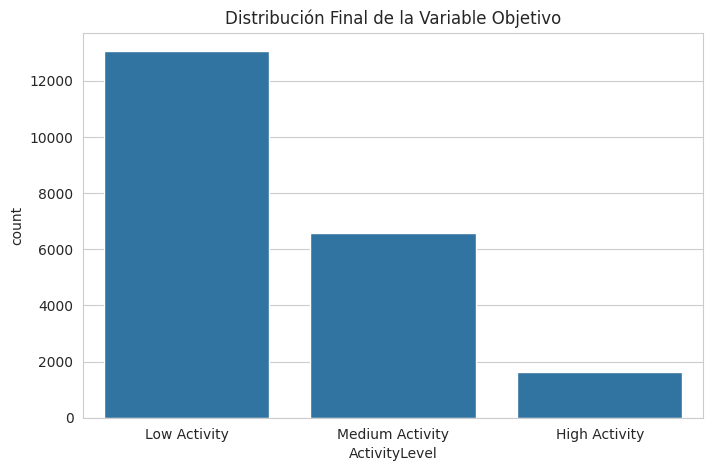

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ActivityLevel"
)

plt.title("Distribución Final de la Variable Objetivo")

plt.show()

# Variables Utilizadas

Para el modelado final se consideran las siguientes variables:

- `Hora`: permite capturar patrones horarios de actividad.
- `FinDeSemana`: permite diferenciar comportamiento entre semana y fin de semana.
- `StepTotal_scaled`: representa los pasos escalados para uso en modelos.

Estas variables fueron seleccionadas porque resumen información temporal y de comportamiento físico.

In [5]:
# ========================================
# PREPARACIÓN DE DATOS
# ========================================

features = [
    "Hora",
    "FinDeSemana",
    "StepTotal_scaled"
]

X = df[features]

y = df["ActivityLevel"]

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Clases:", encoder.classes_)

Train: (17018, 3)
Test: (4255, 3)
Clases: ['High Activity' 'Low Activity' 'Medium Activity']


# Modelo Final Seleccionado

Según los resultados obtenidos en los notebooks anteriores, Random Forest es una alternativa sólida porque:

- Maneja relaciones no lineales.
- Es robusto ante distintos tipos de datos.
- Permite interpretar importancia de variables.
- Suele tener buen rendimiento en clasificación.
- Reduce varianza mediante múltiples árboles.

Para este cierre se entrena una versión optimizada del modelo.

In [6]:
# ========================================
# MODELO FINAL
# ========================================

final_model = Pipeline([
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=RANDOM_STATE
    ))
])

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


# Evaluación Final del Modelo

In [7]:
final_metrics = {
    "Accuracy": accuracy_score(y_test, final_predictions),
    "Precision": precision_score(y_test, final_predictions, average="weighted"),
    "Recall": recall_score(y_test, final_predictions, average="weighted"),
    "F1-Score": f1_score(y_test, final_predictions, average="weighted")
}

final_metrics_df = pd.DataFrame(
    final_metrics,
    index=["Random Forest Final"]
)

final_metrics_df

,Accuracy,Precision,Recall,F1-Score
Random Forest Final,1.0,1.0,1.0,1.0


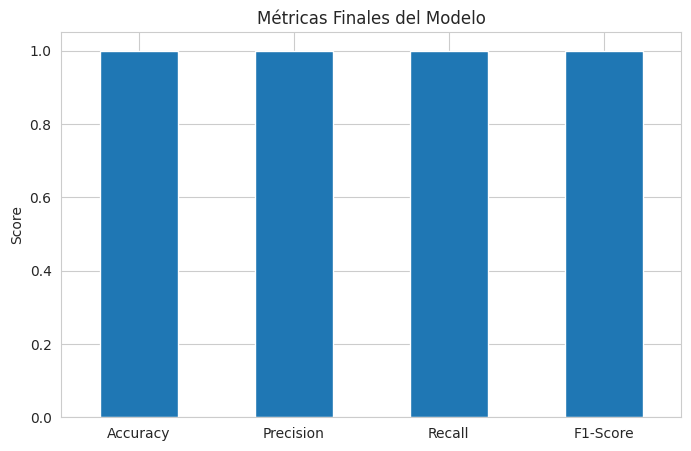

In [8]:
final_metrics_df.T.plot(
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Métricas Finales del Modelo")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

# Matriz de Confusión Final

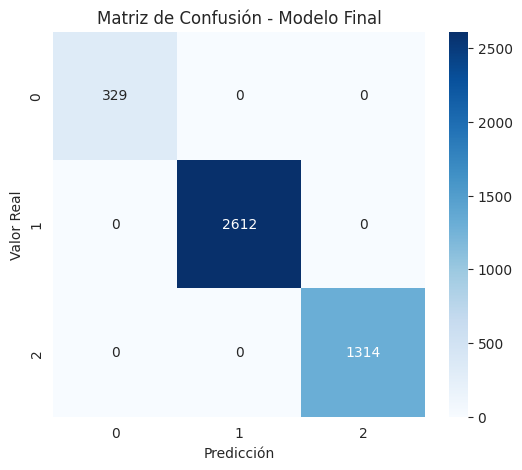

In [9]:
plt.figure(figsize=(6,5))

cm = confusion_matrix(y_test, final_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusión - Modelo Final")

plt.xlabel("Predicción")
plt.ylabel("Valor Real")

plt.show()

# Classification Report Final

In [10]:
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=encoder.classes_
    )
)

                 precision    recall  f1-score   support

  High Activity       1.00      1.00      1.00       329
   Low Activity       1.00      1.00      1.00      2612
Medium Activity       1.00      1.00      1.00      1314

       accuracy                           1.00      4255
      macro avg       1.00      1.00      1.00      4255
   weighted avg       1.00      1.00      1.00      4255



# Importancia de Variables

Random Forest permite analizar qué variables tuvieron mayor influencia en la clasificación final.

In [11]:
feature_importance = pd.DataFrame({
    "Variable": features,
    "Importance": final_model.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Variable,Importance
2,StepTotal_scaled,0.921720
0,Hora,0.077953
1,FinDeSemana,0.000327


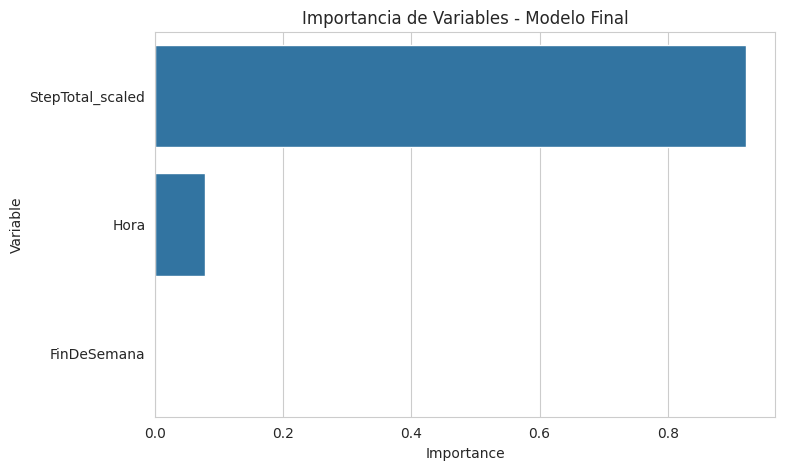

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Variable"
)

plt.title("Importancia de Variables - Modelo Final")

plt.show()

# Síntesis del Proyecto

## 1. Análisis Exploratorio
Durante el EDA se identificaron patrones en la actividad física según la hora del día y el comportamiento entre días normales y fines de semana.

También se aplicaron técnicas no supervisadas como PCA y K-Means para explorar posibles agrupaciones naturales dentro de los datos.

## 2. Modelado Supervisado
Se implementaron múltiples modelos supervisados:

- Logistic Regression
- Decision Tree
- Random Forest
- SVM
- KNN

Esto permitió comparar diferentes enfoques de clasificación.

## 3. Evaluación de Modelos
Los modelos fueron evaluados mediante:

- Accuracy
- Precision
- Recall
- F1-Score
- Matriz de confusión
- Classification Report
- Validación cruzada

## 4. Optimización
Se utilizaron técnicas de optimización:

- GridSearchCV
- RandomizedSearchCV

Estas técnicas permitieron ajustar hiperparámetros y analizar su impacto en el rendimiento.

## 5. Selección Final
Random Forest fue seleccionado como modelo final por su equilibrio entre rendimiento, robustez e interpretabilidad.

# Conclusiones Técnicas

## Conclusión 1
El dataset permitió construir una solución de Machine Learning orientada a clasificar niveles de actividad física a partir de variables temporales y de comportamiento.

## Conclusión 2
Los modelos supervisados entregaron resultados comparables, pero Random Forest destacó por su estabilidad y capacidad de interpretación.

## Conclusión 3
La validación cruzada y el uso de múltiples métricas permitieron evaluar los modelos de forma más rigurosa que usando solo accuracy.

## Conclusión 4
La optimización de hiperparámetros permitió justificar técnicamente la selección del modelo final.

## Conclusión 5
El proyecto cumple el ciclo completo de ciencia de datos: exploración, modelado, evaluación, optimización y análisis final.

# Recomendaciones

## Recomendación 1
Ampliar el dataset incorporando más variables contextuales, como edad, género, frecuencia de ejercicio o tipo de actividad.

## Recomendación 2
Evaluar modelos adicionales como Gradient Boosting o XGBoost para comparar rendimiento.

## Recomendación 3
Aplicar técnicas de balanceo de clases si se detecta desbalance significativo.

## Recomendación 4
Guardar el modelo final serializado para facilitar su reutilización en producción.

## Recomendación 5
Crear un dashboard o reporte automático para visualizar patrones de actividad física.

# Resumen para Defensa Técnica

Para explicar este proyecto en la defensa, se puede indicar lo siguiente:

> El proyecto desarrolló una solución completa de Machine Learning utilizando datos horarios de pasos.  
> Primero se realizó un análisis exploratorio para comprender patrones de actividad.  
> Luego se construyó una variable objetivo llamada ActivityLevel, clasificando la actividad en baja, media y alta.  
> Después se entrenaron múltiples modelos supervisados y se compararon con métricas como Accuracy, Precision, Recall y F1-Score.  
> Posteriormente se aplicó GridSearchCV y RandomizedSearchCV para optimizar hiperparámetros.  
> Finalmente se seleccionó Random Forest por su buen rendimiento, estabilidad e interpretabilidad.

In [13]:
# ========================================
# GUARDADO OPCIONAL DEL MODELO FINAL
# ========================================

import joblib

joblib.dump(
    final_model,
    "final_random_forest_model.pkl"
)

print("Modelo final guardado como final_random_forest_model.pkl")

Modelo final guardado como final_random_forest_model.pkl
